# SynthID-Text from Scratch: Embedding a Watermark with DeepSeek and Detecting It with a Weighted Mean

1. Prove exactly on a small vocabulary that an explicit Tournament is equivalent to modifying the logits

2. Implement a minimal SynthID logits processor and compare it element by element with Hugging Face

3. Implement the repeated-context mask and Weighted Mean detector from scratch

4. Generate text with DeepSeek and evaluate detection at different lengths

Paper: https://www.nature.com/articles/s41586-024-08025-4

Google reference implementation: https://github.com/google-deepmind/synthid-text

Note: Running the complete generation experiment on an A100 is recommended.

In [1]:
# Colab already includes PyTorch, NumPy, Pandas, SciPy, scikit-learn, and Matplotlib.
%pip -q install "transformers==5.14.1" sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.1 MB/s eta 0:00:00


In [2]:
import json
import math
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from sacrebleu.metrics import CHRF
from scipy.stats import gaussian_kde, norm
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from transformers import (
    AutoModel,
    AutoModelForCausalLM,
    AutoTokenizer,
    LogitsProcessor,
    LogitsProcessorList,
    SynthIDTextWatermarkLogitsProcessor,
    SynthIDTextWatermarkingConfig,
    set_seed,
)

CORPUS_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/en/blog/watermarking_on_aigc/data/kgw_corpus.jsonl"
SHOWCASE_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/en/blog/watermarking_on_aigc/data/kgw_showcase.jsonl"
MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

# Public example configuration from the Hugging Face documentation: nine keys for nine Tournament layers.
KEYS = [654, 400, 836, 123, 340, 443, 597, 160, 57]
NGRAM_LEN = 5
CONTEXT_HISTORY_SIZE = 1024
SAMPLING_TABLE_SEED = 0
SAMPLING_TABLE_SIZE = 2**16

# Google's default Weighted Mean weights decrease linearly from 10 to 1.
WEIGHT_START, WEIGHT_END = 10.0, 1.0

# Score the first 32, 64, 128, and 256 valid positions not excluded by the repeated-context mask.
PREFIXES = [32, 64, 128, 256]
TARGET_FPR = 0.01
THEORETICAL_Z_THRESHOLD = float(norm.ppf(1 - TARGET_FPR))
SEED = 1024

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = (
    (torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16)
    if DEVICE.type == "cuda"
    else torch.float32
)

## 1. Proof

### a. An explicit Tournament is equivalent to modifying the generation probabilities

A one-layer Tournament independently draws two candidates $a,b$ from the original distribution $p$. If their binary scores $g$ differ, the candidate with $g=1$ wins;
if their scores are equal, the first candidate wins (equivalent to choosing a winner uniformly at random).

Let $q=\sum_v p(v)g(v)$. The same distribution can be written directly as

$$p'(v)=p(v)\left(1+g(v)-q\right).$$

We verify by simulation that explicitly drawing two tokens for a match is exactly equivalent to sampling normally after replacing $p$ with $p'$.

### b. Verify that SynthID is unbiased

In [3]:
def explicit_tournament(prob, g):
    """Enumerate every candidate pair and compute the exact distribution after one explicit Tournament layer.

    prob: (vs,) probability distribution; g: (vs,) binary scores; returns: (vs,) winning-token distribution.
    """
    tokens = torch.arange(prob.numel(), device=prob.device)

    # These three matrix operations vectorize the following nested loops:
    # for first in tokens:
    #     for second in tokens:
    #         output[winner(first, second)] += p(first) * p(second)
    first = tokens[:, None].expand(-1, len(prob))
    second = tokens[None, :].expand(len(prob), -1)
    winner = torch.where(g[first] >= g[second], first, second)  # The first token wins a tie.
    joint_prob = prob[:, None] * prob[None, :]
    return torch.zeros_like(prob).scatter_add_(0, winner.flatten(), joint_prob.flatten())


def closed_form_tournament(prob, g):
    """Use the closed-form equation to compute the distribution equivalent to one Tournament layer.

    prob: (vs,) probability distribution; g: (vs,) binary Tournament scores; returns: (vs,) modified distribution.
    """
    q = (prob * g).sum()
    return prob * (1 + g - q)


torch.manual_seed(0)
vs = 100
# Verify equivalence.
prob = torch.randn(vs, dtype=torch.float64).softmax(0)
g = torch.randint(0, 2, (vs,))
torch.testing.assert_close(explicit_tournament(prob, g),
                           closed_form_tournament(prob, g), rtol=1e-12, atol=1e-12)
# Verify that SynthID is unbiased.
mean_closed = torch.stack(
    [closed_form_tournament(prob, torch.randint(0, 2, (vs,))) for _ in range(10_000)]
    ).mean(0)
torch.testing.assert_close(mean_closed, prob, atol=1e-2, rtol=1e-2)
print("Verification passed")

验证成功


## 2. A Minimal SynthID Logits Processor

The implementation below retains only the four components required for exact alignment with Hugging Face: the LCG hash, a fixed binary table, layer-by-layer closed-form updates, and repeated-context skipping. The actual watermark update takes only seven lines in `update_logits`; the rest of `MinimalSynthID` connects it to `model.generate()` and stores recent contexts.

In [4]:
MULTIPLIER = 6_364_136_223_846_793_005


def hash_int64(current, values):
    """The same cumulative int64 LCG hash used by Hugging Face. Its core purpose is to
       compress an ordered sequence of int64 integers into a single int64 hash value.

    Parameters
    ----
    current : (...,) int64 tensor
        Initial hash for each item; its leading shape must broadcast with values[..., 0].
    values : (..., N) int64 tensor
        The N integers absorbed into the hash in order, such as context tokens, a candidate token, or a layer key.

    Returns
    ----
    (...,) int64 tensor
        Hash after all values have been absorbed. Natural int64 overflow is part of the algorithm.
    """
    for value in values.unbind(dim=-1):
        current = (current + value) * MULTIPLIER + 1
    return current


def candidate_g(context, candidates, keys, table):
    """Compute g-values for every candidate token and every Tournament layer under the current context.

    Parameters
    ----
    context : (B, L) int64 tensor
        L = ngram_len - 1
    candidates : (B, vs) int64 tensor
    keys : (m,) int64 tensor
    table : (S,) int64 tensor
        Fixed pseudorandom 0/1 table generated from sampling_table_seed.

    Returns
    ----
    g_values : (B, vs, m) int64 tensor
        Binary score for every candidate token at every Tournament layer.
    context_hash : (B,) int64 tensor
        Hash of the context alone, used to identify repeated contexts.
    """
    # hash(context) -> hash(context, candidate) -> hash(context, candidate, layer_key)
    initial = torch.ones(context.shape[0], device=context.device, dtype=torch.long)
    context_hash = hash_int64(initial, context)                        # (B,)
    hashes = hash_int64(context_hash[:, None], candidates[..., None])  # (B, 1) (B, vs, 1) -> (B, vs)
    hashes = hash_int64(hashes[..., None], keys[None, None, :, None])  # (B, vs, 1), (1, 1, m, 1) -> (B, vs, m)
    # Reduce the hash modulo the table size to retrieve a deterministic Bernoulli(0.5) g-value.
    return table[hashes % table.numel()], context_hash


def update_logits(logits, g_values):
    """Convert an explicit m-layer Tournament into an equivalent logits update.

    Parameters
    ----
    logits : (B, vs) floating tensor
        Original logits produced by the language model for vs candidate tokens.
    g_values : (B, vs, m) 0/1 tensor
        Scores for m Tournament layers generated by candidate_g.

    Returns
    ----
    (B, vs) floating tensor
        Modified log probabilities.
    """
    probs = logits.softmax(dim=-1)
    for layer in range(g_values.shape[-1]):
        g = g_values[..., layer].to(probs.dtype)        # (B, vs)
        g_mass = (probs * g).sum(dim=-1, keepdim=True)  # (B,  1)
        probs *= 1 + g - g_mass                         # (B, vs)
    log_probs = probs.log()
    return torch.where(torch.isfinite(log_probs), log_probs, torch.finfo(log_probs.dtype).min)


class MinimalSynthID(LogitsProcessor):
    """A minimal SynthID processor that matches Hugging Face while retaining only essential logic."""

    def __init__(self, ngram_len, keys, sampling_table_size, sampling_table_seed,
                 context_history_size, device):
        """
        Parameters
        ----
        ngram_len : int
            Length of the n-gram used for one g-value; the first n-1 tokens form the context and the last is the candidate token.
        keys : sequence[int]
            Tournament layer keys; the number of keys is the watermark depth m.
        sampling_table_size : int
            Length S of the fixed pseudorandom 0/1 table. A larger table reduces index collisions but consumes more persistent GPU memory.
        sampling_table_seed : int
            Public reproducibility seed used to generate the pseudorandom table; embedding and detection must use the same value.
        context_history_size : int
            Number of recent context hashes to retain. Watermarking is skipped for a repeated context to satisfy the distortion-free condition for one sequence.
        device : str
        """
        self.ngram_len, self.device = ngram_len, torch.device(device)
        self.keys = torch.tensor(keys, device=device)
        # The same seed and device produce exactly the same 0/1 table as Hugging Face.
        rng = torch.Generator(device=device).manual_seed(sampling_table_seed)
        self.table = torch.randint(0, 2, (sampling_table_size,), generator=rng, device=device)
        self.history_size = context_history_size
        self.context = self.history = None

    @property
    def depth(self):
        return len(self.keys)

    @torch.no_grad()
    def __call__(self, input_ids, logits):
        """Modify the logits for the current generation step.

        Parameters
        ----
        input_ids : (B, L) int64 tensor
            The complete token sequence currently held by model.generate.
        logits : (B, vs) floating tensor
            Logits for the current generation step before the SynthID watermark is applied.

        Returns
        ----
        (B, vs) floating tensor
            Modified logits for a first-seen context; unchanged input logits for a repeated context.
        """
        B, vs = logits.shape

        # 1. Initialize the context with L zeros; on later steps, shift left and append the latest token.
        if self.context is None:
            self.context = torch.zeros(B, self.ngram_len - 1, dtype=torch.long, device=self.device)
            self.history = torch.zeros(B, self.history_size, dtype=torch.long, device=self.device)
        else:
            self.context = torch.cat((self.context, input_ids[:, -1:]), dim=-1)[:, 1:]
        # 2. Compute g-values of shape (B, vs, m) for all vs vocabulary candidates and all m layer keys.
        candidates = torch.arange(vs, device=self.device)[None].expand(B, -1)
        g_values, context_hash = candidate_g(self.context, candidates, self.keys, self.table)
        # 3. Apply the closed-form Tournament distribution update m times.
        watermarked = update_logits(logits, g_values)
        # 4. Skip watermarking for a reused context, then add every context to the history.
        context_hash = context_hash[:, None]                                 # (B, 1)
        repeated = (self.history == context_hash).any(dim=-1, keepdim=True)  # (B, 1)
        self.history = torch.cat((context_hash, self.history), dim=-1)[:, :-1]
        return torch.where(repeated, logits, watermarked)

## 3. Weighted Mean Watermark Detection

Detection does not require another language-model pass; it needs only the tokenizer, keys, and matching hash configuration. For $T$ positions not excluded by the repeated-context mask and $m$ layers of g-values, the Weighted Mean is

$$S=\frac{1}{T\sum_l w_l}\sum_{t=1}^{T}\sum_{l=1}^{m}w_l g_{t,l}.$$

Earlier Tournament layers carry stronger signals, so the default weights decrease linearly from 10 to 1. Under the null hypothesis (the watermark is absent),
$g_{t,l}\sim\mathrm{Bernoulli}(0.5)$, so $\mathbb E[S]=0.5$. If the terms are approximately independent,

$$\mathrm{Var}(S)=\frac{0.25\sum_l w_l^2}{T(\sum_l w_l)^2}.$$

The raw Weighted Mean is the core detection score. The z-score below only normalizes for text length so that one theoretical threshold can be used. The public implementation likewise recommends calibrating a separate threshold for each length when raw scores are compared across texts of different lengths.





In [5]:
def sequence_g_values(input_ids, processor):
    """Reconstruct g-values for a complete sequence on the detector side.

    Parameters
    ----
    input_ids : (B, L) int64 tensor
        Complete token sequence to inspect, excluding the prompt.
    processor : MinimalSynthID
        Provides ngram_len, keys, and the sampling table; must match the embedding configuration.

    Returns
    ----
    (B, L-ngram_len+1, m) int64 tensor
        g-values for every complete n-gram across m Tournament layers.
    """
    ngrams = input_ids.unfold(1, processor.ngram_len, 1)  # (B, L-ngram_len+1, ngram_len)
    _ones = torch.ones(ngrams.shape[:2], dtype=torch.long, device=input_ids.device) # (B, L-ngram_len+1)
    hashes = hash_int64(_ones, ngrams)                                          # (B, L-ngram_len+1)
    hashes = hash_int64(hashes[..., None], processor.keys[None, None, :, None]) # (B, L-ngram_len+1, m)
    return processor.table[hashes % processor.table.numel()]


def repetition_mask(input_ids, processor):
    """Mask the second and later occurrences of the same context on the detector side.

    Parameters
    ----
    input_ids : (B, L) int64 tensor
        Token sequence to inspect, identical to the input of sequence_g_values.
    processor : MinimalSynthID
        Provides ngram_len and context_history_size.

    Returns
    ----
    (B, L-ngram_len+1) bool tensor
        True for the first occurrence of a context and False otherwise.
    """
    contexts = input_ids[:, :-1].unfold(1, processor.ngram_len - 1, 1)
    history = torch.zeros(
        input_ids.shape[0], processor.history_size, dtype=torch.long, device=input_ids.device
    )
    mask = []
    for context in contexts.unbind(dim=1):
        context_hash = hash_int64(
            torch.ones(input_ids.shape[0], dtype=torch.long, device=input_ids.device), context
        )[:, None]
        mask.append(~(history == context_hash).any(dim=-1, keepdim=True))
        history = torch.cat((context_hash, history), dim=-1)[:, :-1]
    return torch.cat(mask, dim=-1)


class SynthIDWeightedMeanDetector:
    """Reconstruct g-values from token IDs, apply the repeated-context mask, and compute a Weighted Mean."""

    def __init__(self, processor, weights=None):
        self.processor = processor
        if weights is None:
            weights = torch.linspace(
                WEIGHT_START, WEIGHT_END, processor.depth, dtype=torch.float64,
                device=processor.device,
            )
        self.weights = torch.as_tensor(weights, dtype=torch.float64, device=processor.device)
        if self.weights.shape != (processor.depth,) or (self.weights < 0).any() or self.weights.sum() <= 0:
            raise ValueError("weights must contain one non-negative value per Tournament layer")

    def weighted_mean(self, g_values, mask):
        """Compute the officially defined Weighted Mean in batches; output shape: (B,)."""
        weights = self.weights.to(g_values.device)
        masked = g_values.to(torch.float64) * mask[..., None].to(torch.float64)
        count = mask.sum(dim=1)
        return (masked * weights).sum(dim=(1, 2)) / (count * weights.sum())

    def null_std(self, tokens):
        """Standard deviation of the Weighted Mean under the independent Bernoulli(0.5) approximation."""
        weights = self.weights
        variance = 0.25 * float((weights.square().sum() / weights.sum().square())) / tokens
        return math.sqrt(variance)

    def raw_threshold(self, tokens, z_threshold):
        """Convert a common z threshold into a raw Weighted Mean threshold for the specified effective length."""
        return 0.5 + z_threshold * self.null_std(tokens)

    def __call__(self, token_ids, max_scored_tokens=None):
        """Detect a SynthID watermark in one token sequence.

        token_ids : (L,) sequence or int64 tensor
            Token IDs of the text to inspect, excluding the prompt.
        max_scored_tokens : int or None
            Use only the first N positions not excluded by the repeated-context mask; None uses all valid positions.
        returns : dict or None
            Effective length, Weighted Mean, null-hypothesis standard deviation, z-score, normal-approximation p-value, and per-layer means;
            returns None if the text is too short or has no valid positions.
        """
        # 1. Convert the input into a one-dimensional token sequence on the target device.
        ids = torch.as_tensor(token_ids, dtype=torch.long, device=self.processor.device)
        if ids.numel() < self.processor.ngram_len:
            return None

        # 2. Reconstruct g-values for every complete n-gram and exclude repeated contexts.
        batch = ids[None, :]
        g_values = sequence_g_values(batch, self.processor)
        mask = repetition_mask(batch, self.processor)
        valid_g = g_values[0, mask[0]]
        if max_scored_tokens is not None:
            valid_g = valid_g[:max_scored_tokens]
        tokens = int(valid_g.shape[0])
        if tokens == 0:
            return None

        # 3. Aggregate over valid positions and Tournament layers, then convert using the null variance.
        valid_mask = torch.ones(1, tokens, dtype=torch.bool, device=ids.device)
        score = float(self.weighted_mean(valid_g[None, :], valid_mask)[0])
        std = self.null_std(tokens)
        z = (score - 0.5) / std

        # 4. Return both the raw score and length-normalized result for use with different thresholds.
        return {
            "tokens": tokens,
            "weighted_mean": score,
            "null_std": std,
            "z": z,
            "p_normal": float(norm.sf(z)),
            "layer_means": valid_g.to(torch.float32).mean(dim=0).cpu().tolist(),
        }

In [6]:
def is_watermarked(z_score: float, threshold: float = THEORETICAL_Z_THRESHOLD) -> bool:
    """Return whether the length-normalized Weighted Mean z-score exceeds the threshold."""
    return z_score > threshold


def detect_ids(
    ids: Sequence[int],
    threshold: float = THEORETICAL_Z_THRESHOLD,
    max_scored_tokens: int | None = None,
) -> dict:
    """Detect a token sequence; max_scored_tokens fixes the number of valid contexts."""
    result = detector(ids, max_scored_tokens=max_scored_tokens)
    if result is None:
        return {"detected": False, "reason": "Text is too short or has no scorable context"}
    return {
        **result,
        "raw_threshold": detector.raw_threshold(result["tokens"], threshold),
        "z_threshold": threshold,
        "detected": is_watermarked(result["z"], threshold),
    }


def detect_text(text: str, threshold: float = THEORETICAL_Z_THRESHOLD) -> dict:
    """Tokenize plain text and detect the SynthID-Text watermark for the public configuration."""
    ids = tokenizer(text, add_special_tokens=False).input_ids
    return detect_ids(ids, threshold)

## 4. Elementwise Comparison with the Official Hugging Face Implementation

Feed identical logits to the minimal and official processors while simulating consecutive generation calls. The final call deliberately reuses an earlier four-token context, so the elementwise assertion fails if the hash, g-values, layerwise probability updates, generation state, or repeated-context skipping differs at any point.

In [7]:
CONFIG = dict(
    ngram_len=NGRAM_LEN,
    keys=KEYS,
    sampling_table_size=SAMPLING_TABLE_SIZE,
    sampling_table_seed=SAMPLING_TABLE_SEED,
    context_history_size=CONTEXT_HISTORY_SIZE,
)

# The comparison needs only matching vocabulary indices; no language-model download is required.
TEST_DEVICE, TEST_VOCAB_SIZE = DEVICE, 4096
scratch = MinimalSynthID(**CONFIG, device=TEST_DEVICE)
official_config = SynthIDTextWatermarkingConfig(**CONFIG)
official = SynthIDTextWatermarkLogitsProcessor(
    **official_config.to_dict(), device=TEST_DEVICE
)
assert torch.equal(scratch.table, official.sampling_table)

# The consecutive inputs include a repeated context; both processors must match elementwise on first and repeated occurrences.
running_ids = torch.tensor([[11, 22]], device=TEST_DEVICE)
generator = torch.Generator(device=TEST_DEVICE).manual_seed(SEED)
for next_id in [33, 44, 55, 66, 33, 44, 55, 66, 99]:
    scores = torch.randn(1, TEST_VOCAB_SIZE, generator=generator, device=TEST_DEVICE)
    torch.testing.assert_close(
        scratch(running_ids, scores), official(running_ids, scores), rtol=1e-6, atol=1e-6
    )
    running_ids = torch.cat(
        (running_ids, torch.tensor([[next_id]], device=TEST_DEVICE)), dim=1
    )

# The Weighted Mean matches a direct tensor expression of the public formula.
detector_processor = MinimalSynthID(**CONFIG, device=TEST_DEVICE)
detector = SynthIDWeightedMeanDetector(detector_processor)
test_g = torch.randint(0, 2, (2, 7, len(KEYS)), device=TEST_DEVICE)
test_mask = torch.tensor(
    [[1, 1, 0, 1, 1, 0, 1], [1, 0, 1, 1, 0, 1, 1]],
    dtype=torch.bool,
    device=TEST_DEVICE,
)
weights = torch.linspace(10, 1, len(KEYS), dtype=torch.float64, device=TEST_DEVICE)
reference_score = (
    (test_g.to(torch.float64) * test_mask[..., None] * weights).sum(dim=(1, 2))
    / (test_mask.sum(dim=1) * weights.sum())
)
torch.testing.assert_close(detector.weighted_mean(test_g, test_mask), reference_score)
print("The minimal SynthID logits processor matches Hugging Face elementwise; the Weighted Mean formula is verified")

极简synthid logits processor与Hugging Face逐元素一致；Weighted Mean公式验证通过


## 5. Generating Paraphrases

As in the KGW experiment, we use the faster DeepSeek-R1-Distill-Qwen-1.5B and close `<think>` in the prompt;
if the model starts reasoning again, we keep only the original generated tokens after the final `</think>`. A new logits processor is created for every generation
so that context history from one passage never carries into the next.





In [8]:
# The experimental corpus, tokenizer, and model are downloaded only from this point onward.
data = pd.read_json(CORPUS_URL, lines=True)
showcase_original = pd.read_json(SHOWCASE_URL, lines=True).text.iloc[0]
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"  # Batched generation with a decoder-only model requires left padding.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=DTYPE, attn_implementation="sdpa"
).to(DEVICE).eval()
MODEL_DEVICE, VOCAB_SIZE = next(model.parameters()).device, model.config.vocab_size
print("Corpus passages:", len(data), "Device:", MODEL_DEVICE, "Vocabulary size:", VOCAB_SIZE)

THINK_OPEN_IDS = tokenizer("<think>", add_special_tokens=False).input_ids
THINK_CLOSE_IDS = tokenizer("</think>", add_special_tokens=False).input_ids
THINK_PREFILL_IDS = tokenizer("</think>\n", add_special_tokens=False).input_ids


def prompt_inputs(texts):
    """Construct a padded batch of R1 chat inputs and close each reasoning block in the prompt."""
    conversations = []
    for text in texts:
        chars = len("".join(text.split()))
        content = (
            "Faithfully paraphrase the text below. Preserve all facts, logical relationships, and conclusions, but use your own wording. "
            f"Keep the paraphrase roughly the same length as the source (approximately {chars} non-whitespace characters; ±10% is allowed). "
            "Do not add analysis or a preamble. Output only the paraphrased text.\n\nSource text:\n" + text
        )
        conversations.append([{"role": "user", "content": content}])
    inputs = tokenizer.apply_chat_template(
        conversations, add_generation_prompt=True, tokenize=True, padding=True,
        return_dict=True, return_tensors="pt",
    )
    close = torch.tensor(THINK_PREFILL_IDS)[None].expand(len(texts), -1)
    inputs["input_ids"] = torch.cat([inputs["input_ids"], close], dim=1)
    inputs["attention_mask"] = torch.cat(
        [inputs["attention_mask"], torch.ones_like(close)], dim=1
    )
    return inputs.to(MODEL_DEVICE)


def find_last(ids: list[int], pattern: list[int]) -> int:
    """Return the start of the final complete pattern, or -1 if no match exists."""
    return next(
        (index for index in range(len(ids) - len(pattern), -1, -1)
         if ids[index:index + len(pattern)] == pattern),
        -1,
    )


def body_tokens(ids: list[int]) -> tuple[list[int], bool]:
    """If R1 reasons again, retain only the body tokens after the final </think>."""
    close = find_last(ids, THINK_CLOSE_IDS)
    if close >= 0:
        return ids[close + len(THINK_CLOSE_IDS):], True
    return ([], False) if find_last(ids, THINK_OPEN_IDS) >= 0 else (ids, True)


class GenerationNLLRecorder(LogitsProcessor):
    """Reuse the original model logits during generation to record the NLL of every generated token."""

    def __init__(self, model):
        self.current = self.previous = None
        self.steps = []
        # Capture the original logits directly from the output layer before watermarking, temperature, and top-p.
        self.hook = model.get_output_embeddings().register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.current = output[:, -1].detach().clone()

    def _nll(self, token_ids):
        logits = self.previous.float()
        selected = logits.gather(1, token_ids[:, None]).squeeze(1)
        return torch.logsumexp(logits, dim=-1) - selected

    @torch.no_grad()
    def __call__(self, input_ids, scores):
        # At step t+1, input_ids contains the token actually sampled at step t.
        if self.previous is not None:
            self.steps.append(self._nll(input_ids[:, -1]))
        self.previous, self.current = self.current, None
        return scores

    def finish(self, sequences):
        """Record the final generated token and return NLLs aligned position by position with generated tokens."""
        self.steps.append(self._nll(sequences[:, -1]))
        return torch.stack(self.steps, dim=1).cpu().tolist()

    def close(self):
        self.hook.remove()


@torch.inference_mode()
def generate_batch(texts, watermarked, seed=SEED):
    """Generate text in batches while recording the body's mean per-token NLL under the original model."""
    set_seed(seed)
    inputs = prompt_inputs(texts)
    source_tokens = tokenizer(texts, add_special_tokens=False).input_ids
    kwargs = dict(
        do_sample=True, temperature=1, top_p=0.95,
        max_new_tokens=max(
            min(512, max(128, math.ceil(len(tokens) * 1.15)))
            for tokens in source_tokens
        ),
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    recorder = GenerationNLLRecorder(model)
    processors = [recorder]
    if watermarked:
        processors.append(MinimalSynthID(**CONFIG, device=MODEL_DEVICE))
    kwargs["logits_processor"] = LogitsProcessorList(processors)

    try:
        sequences = model.generate(**inputs, **kwargs)
        token_nlls = recorder.finish(sequences)
    finally:
        recorder.close()
    outputs = sequences[:, inputs["input_ids"].shape[1]:].tolist()
    stop_ids = {tokenizer.eos_token_id, tokenizer.pad_token_id}
    result = []
    for output, nlls in zip(outputs, token_nlls):
        stop = next(
            (i for i, token in enumerate(output) if token in stop_ids), len(output)
        )
        output = output[:stop]
        output, valid = body_tokens(output)
        # body_tokens can retain only a suffix of the original sequence, so take the matching NLL suffix.
        body_nlls = nlls[stop - len(output):stop] if output else []
        text_out = tokenizer.decode(output, skip_special_tokens=True).strip()
        result.append({
            "watermarked": watermarked, "seed": seed, "batch_size": len(texts),
            "text": text_out,
            "token_ids": output,
            "nll0": sum(body_nlls) / len(body_nlls) if body_nlls else None,
            "valid": valid and bool(text_out),
        })
    return result


def generate(text, watermarked, seed=SEED):
    """Generate one item as a convenience wrapper for the showcase."""
    return generate_batch([text], watermarked, seed)[0]

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

语料段落数： 675 运行设备： cuda:0 词表大小： 151936


## 6. Qualitative Example and Text-quality Metrics

Generate unwatermarked and SynthID-Text-watermarked versions of the same source and inspect their Weighted Means. Per-layer g-value
means are aggregated over all samples at a fixed effective length in the main experiment, avoiding random fluctuations from a single passage.





In [9]:
showcase = [generate(showcase_original, mode) for mode in (False, True)]
if not all(item["valid"] for item in showcase):
    raise ValueError("The showcase contains unfinished reasoning or an empty body; change SEED and try again")

display(Markdown("## Original\n" + showcase_original))
for item in showcase:
    mode = "watermarked" if item["watermarked"] else "unwatermarked"
    display(Markdown(f"## {mode}\n" + item["text"]))

## 原文
相比同类图书，本书在理论基础和工程实现上都独具特色。

- 在理论基础方面，内容涉及统计分析、机器学习、计量经济学等多个学科，本书通过类比打通学科之间的隔阂，并借鉴经典模型的搭建经验，系统梳理从基础模型到大语言模型的发展脉络。

- 在工程实现方面，本书不满足于调用封装良好的第三方工具，而是重新实现经典模型的核心部分，让读者能够通过代码直接理解模型的核心结构与关键算法细节。

## unwatermarked
相比同类图书，本书在理论基础和工程实现上都独具特色。

在理论基础方面，内容涉及统计分析、机器学习、计量经济学等多个学科，通过类比打通学科之间的隔阂，并借鉴经典模型的搭建经验，系统梳理从基础模型到大语言模型的发展脉络。

在工程实现方面，本书不满足于调用封装良好的第三方工具，而是重新实现经典模型的核心部分，让读者能够通过代码直接理解模型的核心结构与关键算法细节。

## watermarked
相比同类图书，本书在理论基础和工程实现上都独具特色。

在理论基础方面，内容涉及统计分析、机器学习、计量经济学等多个学科，本书通过类比打通学科之间的隔阂，并借鉴经典模型的搭建经验，系统梳理从基础模型到大语言模型的发展脉络。

在工程实现方面，本书不满足于调用封装良好的第三方工具，而是重新实现经典模型的核心部分，让读者能够通过代码直接理解模型的核心结构与关键算法细节。

In [10]:
showcase_detection = [{"mode": "original", **detect_text(showcase_original)}]
showcase_detection += [
    {"mode": "watermarked" if item["watermarked"] else "unwatermarked",
     **detect_ids(item["token_ids"])}
    for item in showcase
]
display(pd.DataFrame(showcase_detection).drop(columns="layer_means", errors="ignore"))

,mode,tokens,weighted_mean,null_std,z,p_normal,raw_threshold,z_threshold,detected
0,original,101,0.517427,0.018755,0.929192,0.176395,0.543630,2.326348,False
1,unwatermarked,98,0.529607,0.019040,1.555036,0.059969,0.544293,2.326348,False
2,watermarked,99,0.529640,0.018943,1.564667,0.058830,0.544069,2.326348,False


In [11]:
chrf = CHRF()
bge_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-zh-v1.5")
bge = AutoModel.from_pretrained("BAAI/bge-small-zh-v1.5").to(MODEL_DEVICE).eval()


@torch.inference_mode()
def embeddings(texts, batch_size=32):
    """Compute normalized BGE sentence embeddings in batches and return a CPU tensor."""
    result = []
    for start in range(0, len(texts), batch_size):
        batch = bge_tokenizer(
            texts[start:start + batch_size], padding=True, truncation=True,
            max_length=512, return_tensors="pt",
        ).to(MODEL_DEVICE)
        result.append(F.normalize(bge(**batch).last_hidden_state[:, 0], dim=-1).cpu())
    return torch.cat(result)


def similarity(reference: str | list[str], candidate: str | list[str]) -> pd.DataFrame:
    """Compute chrF, semantic cosine similarity, and the token-length ratio."""
    references = [reference] if isinstance(reference, str) else reference
    candidates = [candidate] if isinstance(candidate, str) else candidate
    if len(references) == 1:
        references = references * len(candidates)
    reference_emb, candidate_emb = embeddings(references), embeddings(candidates)
    reference_ids = tokenizer(references, add_special_tokens=False).input_ids
    candidate_ids = tokenizer(candidates, add_special_tokens=False).input_ids
    return pd.DataFrame({
        "chrF": [
            chrf.sentence_score(candidate_text, [reference_text]).score / 100
            for reference_text, candidate_text in zip(references, candidates)
        ],
        "Semantic cosine": (reference_emb * candidate_emb).sum(dim=1).numpy(),
        "Length ratio": [
            len(candidate_tokens) / len(reference_tokens)
            for reference_tokens, candidate_tokens in zip(reference_ids, candidate_ids)
        ],
    })


unwatermarked_showcase, watermarked_showcase = showcase
comparisons = [
    ("Unwatermarked vs original", showcase_original, unwatermarked_showcase["text"]),
    ("Watermarked vs unwatermarked", unwatermarked_showcase["text"], watermarked_showcase["text"]),
]
for title, reference, candidate in comparisons:
    display(Markdown(f"### {title}"), similarity(reference, candidate))

config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/439k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

### Unwatermarked vs original

,chrF,Semantic cosine,Length ratio
0,0.939844,0.99691,0.971429


### Watermarked vs unwatermarked

,chrF,Semantic cosine,Length ratio
0,0.983418,0.998844,1.009804


## 7. Main Experiment

The full corpus is grouped into batches of similar lengths to generate unwatermarked and watermarked versions. During generation, we record each body's NLL under the original model and aggregate per-layer g-values at fixed effective lengths. Results are appended to JSONL one item at a time so an interrupted Colab run can resume. The detection threshold is fixed in advance at the one-sided 1% threshold from the independent Bernoulli(0.5) approximation, with no calibration on test data; we finally report empirical FPR, TPR, and ROC-AUC.





In [12]:
# Set to 20 while debugging; None uses the full corpus.
MAX_SAMPLES = None
BATCH_SIZE = 200
sources = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
if MAX_SAMPLES:
    sources = sources.head(MAX_SAMPLES).copy()
# Sort by length in descending order: run the longest batches first so shorter batches can reuse allocated GPU memory.
sources["source_tokens"] = [
    len(ids) for ids in tokenizer(sources["text"].tolist(), add_special_tokens=False).input_ids
]
sources = sources.sort_values("source_tokens", ascending=False).reset_index(drop=True)
print("Experiment passages:", len(sources))

# NLL must be recorded during generation; use a new file to avoid mixing in results from an older version.
RESULTS = Path("/content/synthid_weighted_mean_v2.jsonl")
records = [json.loads(line) for line in RESULTS.open(encoding="utf-8")] if RESULTS.exists() else []
done = {
    (int(row["source_id"]), bool(row["watermarked"]))
    for row in records if row.get("valid", False) and row.get("nll0") is not None
}
tasks = [
    (source, mode)
    for source in sources.itertuples(index=False)
    for mode in (False, True)
]
completed = sum((int(source.id), mode) in done for source, mode in tasks)
print(f"Total tasks:{len(tasks)}，completed:{completed}，remaining:{len(tasks) - completed}")

with RESULTS.open("a", encoding="utf-8") as output:
    for start in range(0, len(sources), BATCH_SIZE):
        batch = list(sources.iloc[start:start + BATCH_SIZE].itertuples(index=False))
        texts = [source.text for source in batch]
        # Use the same seed for unwatermarked and watermarked versions of the same batch.
        for mode in (False, True):
            pending_indices = [
                index for index, source in enumerate(batch)
                if (int(source.id), mode) not in done
            ]
            if len(pending_indices) == 0:
                continue
            generated_batch = generate_batch(texts, mode, SEED)
            for index in pending_indices:
                source, item = batch[index], generated_batch[index]
                task = (int(source.id), mode)
                row = {
                    "source_id": int(source.id),
                    "source_text": source.text,
                    **item,
                }
                output.write(json.dumps(row, ensure_ascii=False) + "\n")
                output.flush()
                records.append(row)
                done.add(task)
                completed += 1
            if completed % 100 == 0:
                print(f"[{completed}/{len(tasks)}] saved", flush=True)

valid_records = [
    row for row in records if row.get("valid", False) and row.get("nll0") is not None
]
generated = pd.DataFrame(valid_records)
print(f"Valid generations:{len(valid_records)}，invalid generations:{len(records) - len(valid_records)}")

实验段落数： 675
总任务数：1350，已完成：0，待生成：1350
[200/1350] 已保存
[400/1350] 已保存
[600/1350] 已保存
[800/1350] 已保存
[1000/1350] 已保存
[1200/1350] 已保存
有效生成结果：1348，无效结果：2


In [13]:
unwatermarked = generated[~generated["watermarked"]][["source_id", "text", "nll0"]]
watermarked = generated[generated["watermarked"]][["source_id", "text", "nll0"]]
pairs = unwatermarked.merge(
    watermarked, on="source_id", suffixes=("_unwatermarked", "_watermarked")
)

# Use the unwatermarked output for the same source as the baseline for measuring changes introduced by watermarking.
quality = similarity(
    pairs["text_unwatermarked"].tolist(), pairs["text_watermarked"].tolist()
)
# A positive value means the watermarked output is less likely under the original model, indicating greater distribution distortion.
quality["Delta NLL"] = (pairs["nll0_watermarked"] - pairs["nll0_unwatermarked"]).to_numpy()
display(quality.agg(["mean", "std"]).round(3))

,chrF,Semantic cosine,Length ratio,Delta NLL
mean,0.434,0.872,1.275,0.155
std,0.297,0.134,2.158,0.525


## 8. Weighted Mean Distributions and Detection Performance at Different Text Lengths

Each passage is scored on its first 32, 64, 128, and 256 valid contexts to make lengths comparable. Unwatermarked raw scores should center on 0.5, and normalized z-scores should approximate $N(0,1)$; the watermarked distribution should shift right as evidence accumulates.





,mode,length,samples,raw_mean,raw_std,z_mean,z_std
0,original,32,675,0.501,0.031,0.022,0.932
1,original,64,675,0.501,0.023,0.028,0.997
2,original,128,674,0.501,0.016,0.084,0.950
3,original,256,200,0.501,0.012,0.051,1.033
4,unwatermarked,32,665,0.500,0.033,-0.001,0.981
5,unwatermarked,64,651,0.501,0.023,0.048,0.988
6,unwatermarked,128,606,0.500,0.016,-0.008,0.954
7,unwatermarked,256,182,0.500,0.011,-0.028,0.921
8,watermarked,32,662,0.548,0.051,1.435,1.526
9,watermarked,64,644,0.548,0.045,2.018,1.890


逐层统计样本数： {'original': 674, 'unwatermarked': 606, 'watermarked': 595}


,layer,weight,original_g_mean,unwatermarked_g_mean,watermarked_g_mean
0,1,10.000,0.500,0.501,0.550
1,2,8.875,0.504,0.501,0.553
2,3,7.750,0.504,0.503,0.550
3,4,6.625,0.506,0.501,0.543
4,5,5.500,0.499,0.496,0.539
5,6,4.375,0.497,0.495,0.534
6,7,3.250,0.497,0.496,0.539
7,8,2.125,0.497,0.500,0.538
8,9,1.000,0.500,0.503,0.536


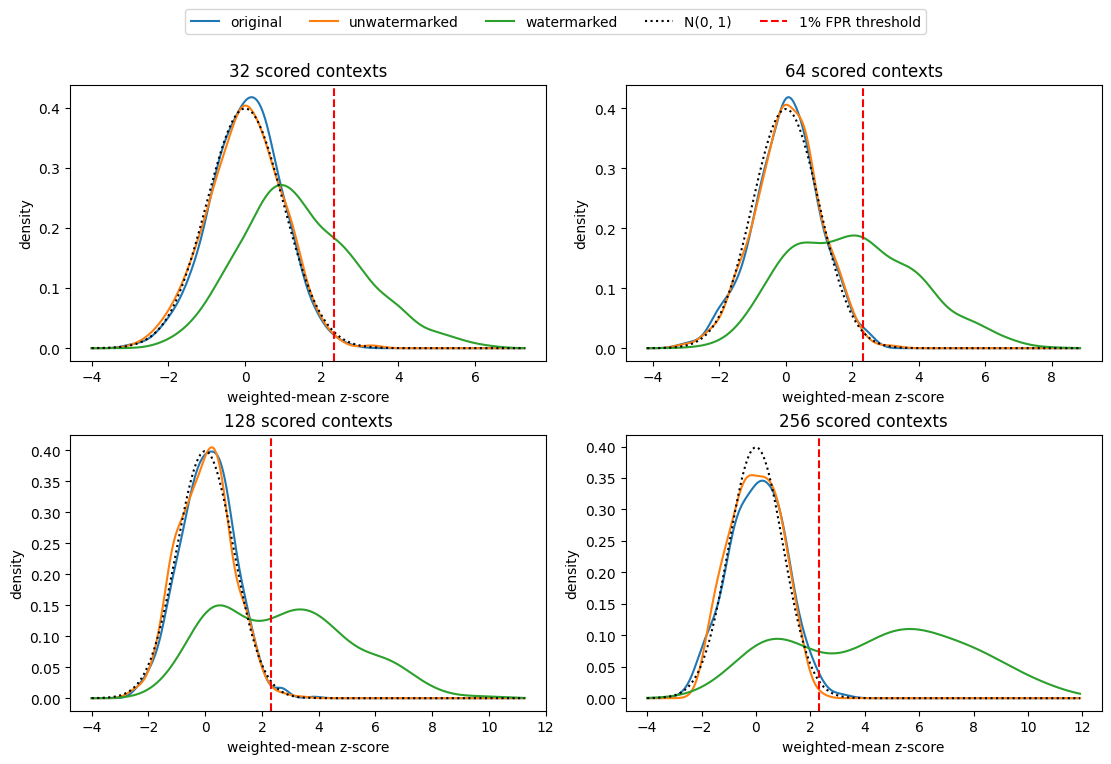

In [14]:
def prefix_scores(ids: Sequence[int], source_id: int, mode: str) -> list[dict]:
    """Compute Weighted Mean scores for the same text at several fixed effective lengths."""
    full = detector(ids)
    if full is None:
        return []
    rows = []
    for length in PREFIXES:
        if full["tokens"] >= length:
            result = detector(ids, max_scored_tokens=length)
            rows.append({
                "source_id": source_id,
                "mode": mode,
                "length": length,
                **result,
            })
    return rows


samples = [
    (source.id, "original", tokenizer(source.text, add_special_tokens=False).input_ids)
    for source in sources.itertuples(index=False)
]
samples += [
    (row["source_id"], "watermarked" if row["watermarked"] else "unwatermarked",
     row["token_ids"])
    for row in valid_records
]
score_rows = [
    score
    for source_id, mode, ids in samples
    for score in prefix_scores(ids, source_id, mode)
]
scores = pd.DataFrame(score_rows)

score_summary = (
    scores.groupby(["mode", "length"])
    .agg(
        samples=("z", "size"),
        raw_mean=("weighted_mean", "mean"),
        raw_std=("weighted_mean", "std"),
        z_mean=("z", "mean"),
        z_std=("z", "std"),
    )
    .reset_index()
)
display(score_summary.round(3))

LAYER_SUMMARY_LENGTH = 128
layer_part = scores[scores["length"] == LAYER_SUMMARY_LENGTH]
layer_summary = pd.DataFrame({
    "layer": np.arange(1, len(KEYS) + 1),
    "weight": detector.weights.cpu().numpy(),
    **{
        f"{mode}_g_mean": np.stack(group["layer_means"]).mean(axis=0)
        for mode, group in layer_part.groupby("mode")
    },
})
print("Per-layer sample counts:", layer_part.groupby("mode").size().to_dict())
display(layer_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
colors = {"original": "tab:blue", "unwatermarked": "tab:orange", "watermarked": "tab:green"}
for axis, length in zip(axes.flat, PREFIXES):
    part = scores[scores["length"] == length]
    x = np.linspace(min(-4, part["z"].min() - 1), max(4, part["z"].max() + 1), 300)
    for mode, color in colors.items():
        values = part.loc[part["mode"] == mode, "z"]
        if len(values) > 1 and values.std() > 0:
            axis.plot(x, gaussian_kde(values)(x), color=color, linewidth=1.5, label=mode)
    axis.plot(x, norm.pdf(x), "k:", label="N(0, 1)")
    axis.axvline(
        THEORETICAL_Z_THRESHOLD, color="red", linestyle="--", label="1% FPR threshold"
    )
    axis.set(title=f"{length} scored contexts", xlabel="weighted-mean z-score", ylabel="density")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=5)
plt.show()

In [15]:
# Original and unwatermarked samples are negative; watermarked samples are positive.
evaluation = []
for length, part in scores.groupby("length"):
    positive = part["mode"] == "watermarked"
    predicted = part["z"] > THEORETICAL_Z_THRESHOLD
    evaluation.append({
        "length": length,
        "neg_samples": int((~positive).sum()),
        "pos_samples": int(positive.sum()),
        "raw_threshold": detector.raw_threshold(int(length), THEORETICAL_Z_THRESHOLD),
        "ROC-AUC": roc_auc_score(positive, part["weighted_mean"]),
        "Precision": precision_score(positive, predicted, zero_division=0),
        "Recall": recall_score(positive, predicted),
        "FPR": predicted[~positive].mean(),
    })

evaluation = pd.DataFrame(evaluation)
display(evaluation.round(3))

,length,neg_samples,pos_samples,raw_threshold,ROC-AUC,Precision,Recall,FPR
0,32,1340,662,0.578,0.781,0.951,0.266,0.007
1,64,1326,644,0.555,0.812,0.954,0.421,0.010
2,128,1280,595,0.539,0.840,0.964,0.543,0.009
3,256,382,194,0.527,0.891,0.985,0.670,0.005
